## Data loading and initial clean-up

The original dataset is loaded from the Excel file. Since the column names start in the fourth row of the file, the `header=3` parameter is used during import. The column names are standardized, empty non-patient rows are removed and the cleaned dataset is saved as a CSV file for the following preprocessing steps.

In [1]:
import pandas as pd
from pathlib import Path

# load dataset
df = pd.read_excel("data/raw/dataset.xlsx", header=3)

# clean up column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# remove rows that do not have a patient ID
df = df.dropna(subset=["patient"])

# sanity checks
display(df.head())
df.info()

# create processed data directory if it doesn't exist
Path("data/processed").mkdir(parents=True, exist_ok=True)

# save cleaned dataset as a new CSV file
df.to_csv("data/processed/dataset_clean.csv", index=False)

,patient,gender,age_(y),schooling_(y),breastfeeding,varicella,initial_symptom,mono_or_polysymptomatic,oligoclonal_bands,llssep,ulssep,vep,baep,periventricular_mri,cortical_mri,infratentorial_mri,spinal_cord_mri,initial_edss,final_edss,group
0,1.0,1,34.0,20.0,1,1,2,1,0,1,1,0,0,0,1,0,1,1.0,1.0,1
1,2.0,1,61.0,25.0,3,2,10,2,1,1,0,1,0,0,0,0,1,2.0,2.0,1
2,3.0,1,22.0,20.0,3,1,3,1,1,0,0,0,0,0,1,0,0,1.0,1.0,1
3,4.0,2,41.0,15.0,1,1,7,2,1,0,1,1,0,1,1,0,0,1.0,1.0,1
4,5.0,2,34.0,20.0,2,1,6,2,0,1,0,0,0,1,0,0,0,1.0,1.0,1


<class 'pandas.DataFrame'>
RangeIndex: 273 entries, 0 to 272
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   patient                  273 non-null    float64
 1   gender                   273 non-null    object 
 2   age_(y)                  273 non-null    float64
 3   schooling_(y)            272 non-null    float64
 4   breastfeeding            273 non-null    object 
 5   varicella                273 non-null    object 
 6   initial_symptom          272 non-null    object 
 7   mono_or_polysymptomatic  273 non-null    object 
 8   oligoclonal_bands        273 non-null    object 
 9   llssep                   273 non-null    object 
 10  ulssep                   273 non-null    object 
 11  vep                      273 non-null    object 
 12  baep                     273 non-null    object 
 13  periventricular_mri      273 non-null    object 
 14  cortical_mri             273 non-null

### Data inspection

The cleaned CSV file is loaded and inspected before further preprocessing. The dataset shape, target variable distribution, and data types are checked to ensure that the data was saved and loaded correctly.

In [2]:
# load cleaned csv file
df = pd.read_csv("data/processed/dataset_clean.csv")

# check shape of the dataset
print("Dataset shape:", df.shape)

# check distribution of the target variable (group)
print("\nTarget variable distribution:")
print(df["group"].value_counts(dropna=False))

# check data types of the columns
print("\nData types:")
print(df.dtypes)

Dataset shape: (273, 20)

Target variable distribution:
group
2    148
1    125
Name: count, dtype: int64

Data types:
patient                    float64
gender                       int64
age_(y)                    float64
schooling_(y)              float64
breastfeeding                int64
varicella                    int64
initial_symptom            float64
mono_or_polysymptomatic      int64
oligoclonal_bands            int64
llssep                       int64
ulssep                       int64
vep                          int64
baep                         int64
periventricular_mri          int64
cortical_mri                 int64
infratentorial_mri           int64
spinal_cord_mri              int64
initial_edss               float64
final_edss                 float64
group                        int64
dtype: object


## Data preprocessing

In this section, the cleaned CSV file is loaded and prepared for machine learning. This includes checking the target variable, converting coded variables to numeric values, handling missing values, excluding leakage variables, and preparing the data for model training.

### Target variable

The target variable is derived from the `group` column. According to the dataset encoding, `1` represents patients who converted to clinically definite multiple sclerosis (CDMS), while `2` represents patients who remained non-CDMS. For binary classification, the target is recoded so that conversion to CDMS is represented as `1` and no conversion as `0`.

In [3]:
# create copy of the dataset for preprocessing to keep original cleaned dataframe intact
df_model = df.copy()

# recode target variable for binary classification
df_model["conversion"] = df_model["group"].map({
    1: 1,
    2: 0
})

# check if target variable was created correctly
print("Target variable distribution:")
print(df_model["conversion"].value_counts(dropna=False))

Target variable distribution:
conversion
0    148
1    125
Name: count, dtype: int64


### Feature and target separation

The dataset is separated into input features (`X`) and the target variable (`y`). Columns that should not be used for prediction are excluded. The patient identifier is removed because it does not contain clinical information. The original `group` column is removed because it has already been transformed into the binary target variable. The EDSS columns are excluded to avoid data leakage, since EDSS values are only available for patients who converted to CDMS. The `mono_or_polysymptomatic` variable is also excluded in order to improve interpretability due to overlapping information with `intitial_symptoms`.

In [4]:
# define target variable y
y = df_model["conversion"]

# drop columns that are not predictors and create feature matrix X
columns_to_drop = [
    "patient",
    "group",
    "conversion",
    "initial_edss",
    "final_edss",
    "mono_or_polysymptomatic",
]

X = df_model.drop(columns=columns_to_drop)

# check shape of feature matrix and target vector
print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

# sanity check of feature columns
print("\nUpdated feature columns:")
print(X.columns.tolist())
display(X.head())

Feature matrix shape: (273, 15)
Target vector shape: (273,)

Updated feature columns:
['gender', 'age_(y)', 'schooling_(y)', 'breastfeeding', 'varicella', 'initial_symptom', 'oligoclonal_bands', 'llssep', 'ulssep', 'vep', 'baep', 'periventricular_mri', 'cortical_mri', 'infratentorial_mri', 'spinal_cord_mri']


,gender,age_(y),schooling_(y),breastfeeding,varicella,initial_symptom,oligoclonal_bands,llssep,ulssep,vep,baep,periventricular_mri,cortical_mri,infratentorial_mri,spinal_cord_mri
0,1,34.0,20.0,1,1,2.0,0,1,1,0,0,0,1,0,1
1,1,61.0,25.0,3,2,10.0,1,1,0,1,0,0,0,0,1
2,1,22.0,20.0,3,1,3.0,1,0,0,0,0,0,1,0,0
3,2,41.0,15.0,1,1,7.0,1,0,1,1,0,1,1,0,0
4,2,34.0,20.0,2,1,6.0,0,1,0,0,0,1,0,0,0


### Handling unknown values

Some variables use specific numeric codes to represent unknown values. These values are replaced with missing values so that they are not treated as meaningful numerical categories by the model.

In [5]:
import numpy as np

# create copy of feature matrix for preprocessing
X = X.copy()

# define encoding of unknown values in dataset
unknown_value_codes = {
    "breastfeeding": 3,
    "varicella": 3,
    "oligoclonal_bands": 2
}

# replace unknown value codes with NaN
for column, unknown_code in unknown_value_codes.items():
    X[column] = X[column].replace(unknown_code, np.nan)

### Recoding binary variables

Some binary variables are recoded into clearer `0` and `1` values while keeping their original column names. This makes them easier to use in the logistic regression model. The recoding is documented because the meaning of some numeric values changes compared to the original dataset encoding.

In [6]:
# gender:
# original encoding 1 = male, 2 = female
# new encoding 0 = male, 1 = female
X["gender"] = X["gender"].map({
    1: 0,
    2: 1
})

# breastfeeding:
# original encoding 1 = yes, 2 = no, 3 = unknown (already replaced with NaN)
# new encoding 1 = yes, 0 = no
X["breastfeeding"] = X["breastfeeding"].map({
    1: 1,
    2: 0
})

# varicella:
# original encoding 1 = positive, 2 = negative, 3 = unknown (already replaced with NaN)
# new encoding: 1 = positive, 0 = negative
X["varicella"] = X["varicella"].map({
    1: 1,
    2: 0
})

# sanity check after recoding
print(X.shape)
print("\nUpdated feature columns:")
print(X.columns.tolist())
display(X.head())

(273, 15)

Updated feature columns:
['gender', 'age_(y)', 'schooling_(y)', 'breastfeeding', 'varicella', 'initial_symptom', 'oligoclonal_bands', 'llssep', 'ulssep', 'vep', 'baep', 'periventricular_mri', 'cortical_mri', 'infratentorial_mri', 'spinal_cord_mri']


,gender,age_(y),schooling_(y),breastfeeding,varicella,initial_symptom,oligoclonal_bands,llssep,ulssep,vep,baep,periventricular_mri,cortical_mri,infratentorial_mri,spinal_cord_mri
0,0,34.0,20.0,1.0,1.0,2.0,0.0,1,1,0,0,0,1,0,1
1,0,61.0,25.0,NaN,0.0,10.0,1.0,1,0,1,0,0,0,0,1
2,0,22.0,20.0,NaN,1.0,3.0,1.0,0,0,0,0,0,1,0,0
3,1,41.0,15.0,1.0,1.0,7.0,1.0,0,1,1,0,1,1,0,0
4,1,34.0,20.0,0.0,1.0,6.0,0.0,1,0,0,0,1,0,0,0


### Transforming initial symptom

The `initial_symptom` variable contains coded symptom categories and combinations. Since these codes do not represent an ordered numerical scale, the variable is transformed into separate binary symptom indicators for visual, sensory, motor, and other symptoms. This makes the variables easier to interpret clinically and avoids treating the original codes as continuous numerical values.

In [7]:
symptom_mapping = {
    1:  {"visual": 1, "sensory": 0, "motor": 0, "other": 0},
    2:  {"visual": 0, "sensory": 1, "motor": 0, "other": 0},
    3:  {"visual": 0, "sensory": 0, "motor": 1, "other": 0},
    4:  {"visual": 0, "sensory": 0, "motor": 0, "other": 1},
    5:  {"visual": 1, "sensory": 1, "motor": 0, "other": 0},
    6:  {"visual": 1, "sensory": 0, "motor": 1, "other": 0},
    7:  {"visual": 1, "sensory": 0, "motor": 0, "other": 1},
    8:  {"visual": 0, "sensory": 1, "motor": 1, "other": 0},
    9:  {"visual": 0, "sensory": 1, "motor": 0, "other": 1},
    10: {"visual": 0, "sensory": 0, "motor": 1, "other": 1},
    11: {"visual": 1, "sensory": 1, "motor": 1, "other": 0},
    12: {"visual": 1, "sensory": 1, "motor": 0, "other": 1},
    13: {"visual": 1, "sensory": 0, "motor": 1, "other": 1},
    14: {"visual": 0, "sensory": 1, "motor": 1, "other": 1},
    15: {"visual": 1, "sensory": 1, "motor": 1, "other": 1},
}

# create new binary symptom columns
X["symptom_visual"] = X["initial_symptom"].map(
    lambda value: symptom_mapping.get(value, {}).get("visual")
)

X["symptom_sensory"] = X["initial_symptom"].map(
    lambda value: symptom_mapping.get(value, {}).get("sensory")
)

X["symptom_motor"] = X["initial_symptom"].map(
    lambda value: symptom_mapping.get(value, {}).get("motor")
)

X["symptom_other"] = X["initial_symptom"].map(
    lambda value: symptom_mapping.get(value, {}).get("other")
)

# drop  original initial_symptom column
X = X.drop(columns=["initial_symptom"])

# sanity check
print(X.shape)

print("\nNew symptom columns:")
print(X[["symptom_visual", "symptom_sensory", "symptom_motor", "symptom_other"]].head())

print("\nUpdated feature columns:")
print(X.columns.tolist())

(273, 18)

New symptom columns:
   symptom_visual  symptom_sensory  symptom_motor  symptom_other
0             0.0              1.0            0.0            0.0
1             0.0              0.0            1.0            1.0
2             0.0              0.0            1.0            0.0
3             1.0              0.0            0.0            1.0
4             1.0              0.0            1.0            0.0

Updated feature columns:
['gender', 'age_(y)', 'schooling_(y)', 'breastfeeding', 'varicella', 'oligoclonal_bands', 'llssep', 'ulssep', 'vep', 'baep', 'periventricular_mri', 'cortical_mri', 'infratentorial_mri', 'spinal_cord_mri', 'symptom_visual', 'symptom_sensory', 'symptom_motor', 'symptom_other']


### Missing Value Overview

After recoding the variables, the remaining missing values are inspected. This step helps identify which features require imputation before model training.

In [8]:
missing_values = X.isna().sum()

# display columns with at least one missing value
print("Missing values per column:")
print(missing_values[missing_values > 0])

Missing values per column:
schooling_(y)         1
breastfeeding        85
varicella            45
oligoclonal_bands    11
symptom_visual        1
symptom_sensory       1
symptom_motor         1
symptom_other         1
dtype: int64


### Train-test split

The dataset is split into training and test data before imputation and scaling. This prevents information from the test set from influencing the preprocessing steps. A stratified split is used so that both sets keep a similar proportion of converted and non-converted patients.

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2, # 20% of data for testing
    stratify=y, # keep class distribution similar in train and test sets
    random_state=42 # reproducibility
)

# check resulting shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (218, 18)
X_test shape: (55, 18)
y_train shape: (218,)
y_test shape: (55,)


### Class distribution

The class distribution is inspected to check whether the stratified train-test split preserved a similar proportion of conversion and non-conversion cases in both subsets.

In [10]:
# check whether class distribution is similar in train and test sets
print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

# create a table showing class distribution
class_distribution = pd.DataFrame({
    "full dataset": y.value_counts().sort_index(),
    "train set": y_train.value_counts().sort_index(),
    "test set": y_test.value_counts().sort_index()
})

class_distribution.index = ["Non-conversion", "Conversion"]

class_distribution.loc["Total"] = class_distribution.sum()

display(class_distribution)


Training target distribution:
conversion
0    0.541284
1    0.458716
Name: proportion, dtype: float64

Test target distribution:
conversion
0    0.545455
1    0.454545
Name: proportion, dtype: float64


,full dataset,train set,test set
Non-conversion,148,118,30
Conversion,125,100,25
Total,273,218,55


### Handling missing values

Missing values are filled after the train-test split to avoid data leakage. For continuous variables, missing values are replaced with the median value calculated from the training set. For binary variables, missing values are replaced with the most frequent value in the training set. The same imputation values are then applied to the test set.

In [11]:
from sklearn.impute import SimpleImputer

# create copies
X_train_processed = X_train.copy()
X_test_processed = X_test.copy()

# define continuous variables
continuous_features = [
    "age_(y)",
    "schooling_(y)"
]

# define all other binary variables
binary_features = [
    col for col in X_train_processed.columns
    if col not in continuous_features
]

# Create an imputer for continuous variables.
# Missing values are replaced with the median from the training data.
continuous_imputer = SimpleImputer(strategy="median")

# Fit the imputer only on the training data and transform the training data.
X_train_processed[continuous_features] = continuous_imputer.fit_transform(
    X_train_processed[continuous_features]
)

# Apply the same imputation values to the test data.
# Important: we use transform(), not fit_transform(), to avoid data leakage.
X_test_processed[continuous_features] = continuous_imputer.transform(
    X_test_processed[continuous_features]
)

# Create an imputer for binary variables.
# Missing values are replaced with the most frequent value from the training data.
binary_imputer = SimpleImputer(strategy="most_frequent")

# Fit the imputer only on the training data and transform the training data.
X_train_processed[binary_features] = binary_imputer.fit_transform(
    X_train_processed[binary_features]
)

# Apply the same imputation values to the test data.
X_test_processed[binary_features] = binary_imputer.transform(
    X_test_processed[binary_features]
)

# Check whether all missing values were handled.
print("Missing values in training data:", X_train_processed.isna().sum().sum())
print("Missing values in test data:", X_test_processed.isna().sum().sum())

Missing values in training data: 0
Missing values in test data: 0


### Scaling continuous variables

The continuous variables `age_(y)` and `schooling_(y)` are standardized after imputation. The scaler is fitted only on the training data and then applied to both training and test data to avoid data leakage. Binary variables are not scaled.

In [12]:
from sklearn.preprocessing import StandardScaler

# define continuous variables and create a scaler object
continuous_features = [
    "age_(y)",
    "schooling_(y)"
]

scaler = StandardScaler()

# fit the scaler only on the training data
scaler.fit(X_train_processed[continuous_features])

# apply the same scaling to the training and test data
X_train_processed[continuous_features] = scaler.transform(
    X_train_processed[continuous_features]
)

X_test_processed[continuous_features] = scaler.transform(
    X_test_processed[continuous_features]
)

# check the processed training data.
display(X_train_processed.head())

# check shapes
print("X_train_processed shape:", X_train_processed.shape)
print("X_test_processed shape:", X_test_processed.shape)

,gender,age_(y),schooling_(y),breastfeeding,varicella,oligoclonal_bands,llssep,ulssep,vep,baep,periventricular_mri,cortical_mri,infratentorial_mri,spinal_cord_mri,symptom_visual,symptom_sensory,symptom_motor,symptom_other
258,1.0,0.130954,-0.808426,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
73,0.0,-1.641637,-0.076140,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
67,0.0,-0.148928,1.144337,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0
209,1.0,-0.055634,-0.808426,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
128,1.0,2.370017,-0.808426,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0


X_train_processed shape: (218, 18)
X_test_processed shape: (55, 18)


## Feature correlation analysis

Before training and interpreting the logistic regression model, correlations between the predictor variables are inspected. This helps identify strongly related features that may affect the stability and interpretation of model coefficients. The analysis is performed on the processed training data to avoid using information from the test set.

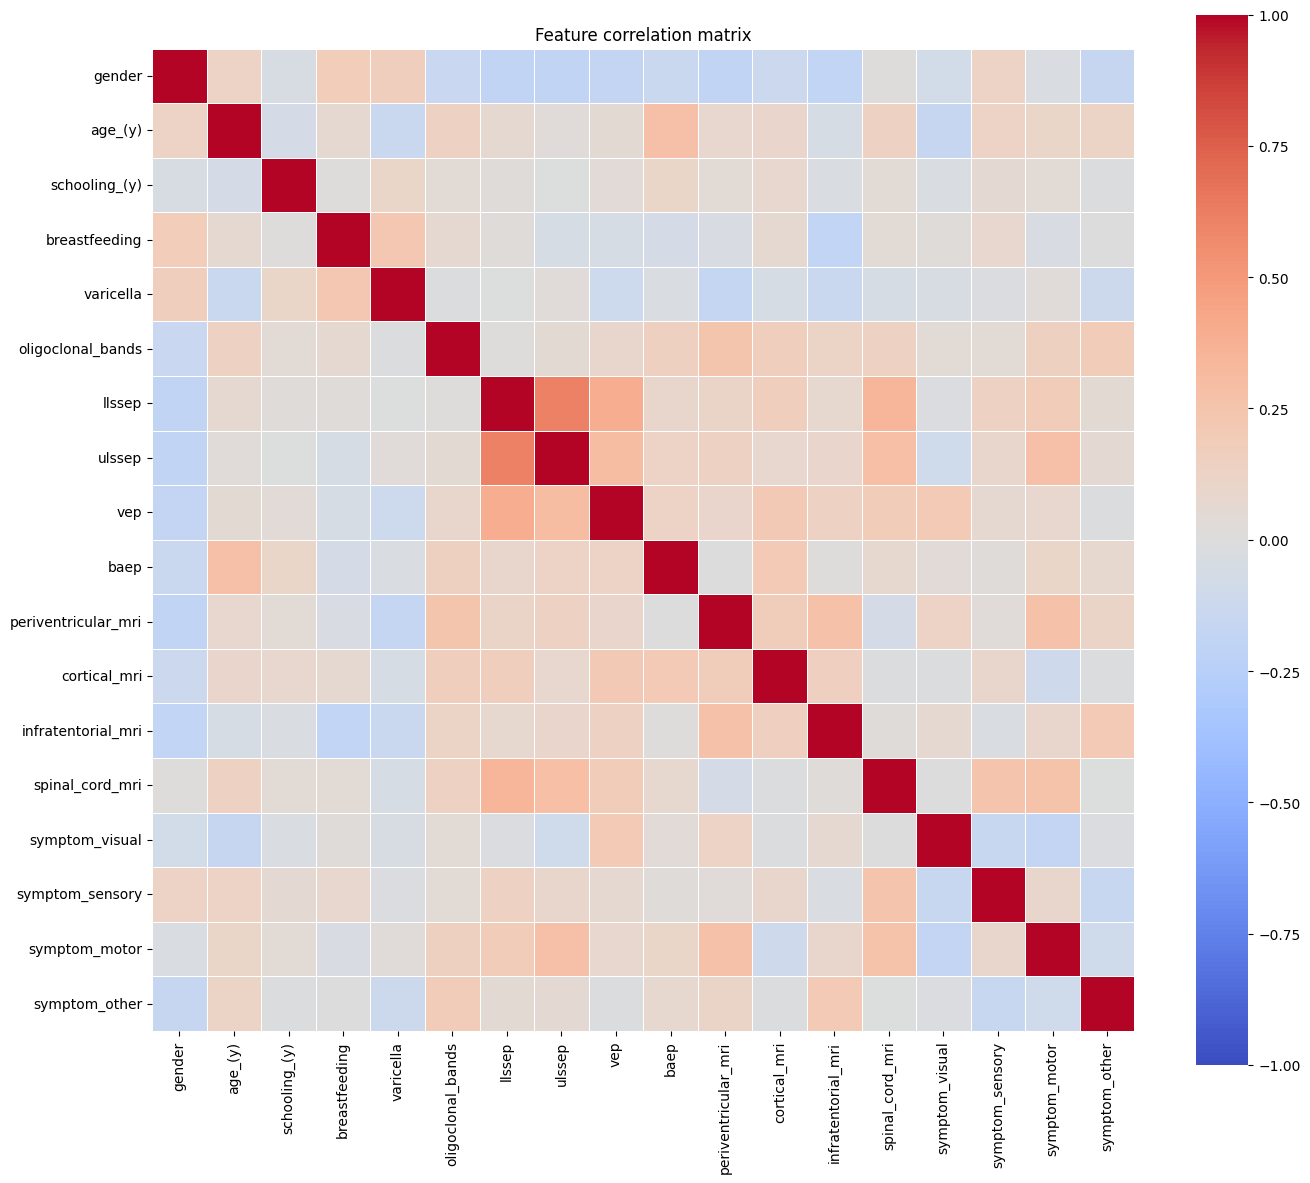

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# create folder for figures if it does not exist
Path("results/figures").mkdir(parents=True, exist_ok=True)

# calculate Pearson correlation matrix on processed training data
correlation_matrix = X_train_processed.corr(method="pearson")

# plot the correlation matrix as a heatmap
plt.figure(figsize=(14, 12))

sns.heatmap(
    correlation_matrix,
    vmin=-1,
    vmax=1,
    center=0,
    cmap="coolwarm",
    square=True,
    linewidths=0.5
)

plt.title("Feature correlation matrix")
plt.tight_layout()

plt.savefig("results/figures/feature_correlation_heatmap_without.png", dpi=300, bbox_inches="tight")

plt.show()

In [14]:
# keep only the upper half of the correlation matrix to avoid showing each pair twice and remove diagonal
upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

# convert the matrix into table of feature pairs
correlation_pairs = upper_triangle.stack().reset_index()
correlation_pairs.columns = ["feature_1", "feature_2", "correlation"]

# add absolute correlation for sorting and threshold checking
correlation_pairs["absolute_correlation"] = correlation_pairs["correlation"].abs()

# show the five strongest correlations
top_5_correlations = correlation_pairs.sort_values(
    by="absolute_correlation",
    ascending=False
).head(5)

display(top_5_correlations)

# show only strong correlations above threshold of 0.7
strong_correlations = correlation_pairs[
    correlation_pairs["absolute_correlation"] >= 0.7
    ]

display(strong_correlations)

,feature_1,feature_2,correlation,absolute_correlation
115,llssep,ulssep,0.614616,0.614616
116,llssep,vep,0.393464,0.393464
121,llssep,spinal_cord_mri,0.344674,0.344674
134,ulssep,vep,0.303663,0.303663
139,ulssep,spinal_cord_mri,0.282798,0.282798


,feature_1,feature_2,correlation,absolute_correlation


## Model training

A logistic regression model is trained on the processed training data. The model is used to predict whether a patient converts from CIS to CDMS.

In [15]:
from sklearn.linear_model import LogisticRegression

# create logistic regression model
model = LogisticRegression(max_iter=1000)

# train the model on the processed training data
model.fit(X_train_processed, y_train)

# check if training worked
print("model training completed")
print("number of features:", X_train_processed.shape[1])

model training completed
number of features: 18


## Model evaluation

The trained model is evaluated on the test set. The evaluation uses accuracy, precision, recall, specificity, F1-score, ROC-AUC, and the confusion matrix.

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import pandas as pd

# predict classes for the test set
y_pred = model.predict(X_test_processed)

# predict probabilities for the positive class
y_pred_proba = model.predict_proba(X_test_processed)[:, 1]

# calculate confusion matrix values
tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()

# calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
specificity = tn / (tn + fp)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# create results table
evaluation_results = pd.DataFrame({
    "metric": [
        "accuracy",
        "precision",
        "recall / sensitivity",
        "specificity",
        "f1-score",
        "roc-auc"
    ],
    "value": [
        accuracy,
        precision,
        recall,
        specificity,
        f1,
        roc_auc
    ]
})

display(evaluation_results)

,metric,value
0,accuracy,0.909091
1,precision,0.884615
2,recall / sensitivity,0.920000
3,specificity,0.900000
4,f1-score,0.901961
5,roc-auc,0.930667


### Confusion matrix

The confusion matrix shows how many patients were correctly and incorrectly classified in each class.

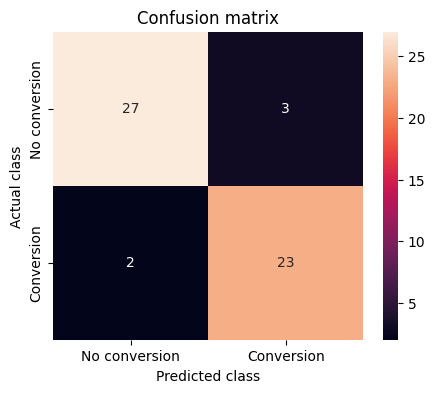

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# create confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

# show confusion matrix as heatmap
plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["No conversion", "Conversion"],
    yticklabels=["No conversion", "Conversion"]
)

plt.xlabel("Predicted class")
plt.ylabel("Actual class")
plt.title("Confusion matrix")
plt.savefig("results/figures/confusion_matrix_without.png", dpi=300, bbox_inches="tight")
plt.show()

### ROC curve

The ROC curve shows how well the model separates patients with and without conversion across different classification thresholds.

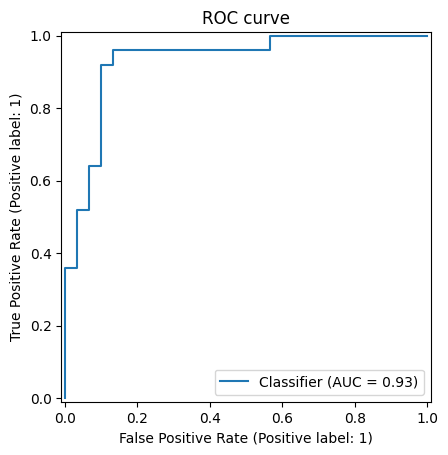

In [ ]:
from sklearn.metrics import RocCurveDisplay

# plot ROC curve
RocCurveDisplay.from_predictions(y_test, y_pred_proba)

plt.title("ROC curve")
plt.savefig("results/figures/roc_curve_without.png", dpi=300, bbox_inches="tight")
plt.show()

## Model interpretation

The logistic regression coefficients are inspected to see which features contribute most to the prediction. Positive coefficients increase the predicted probability of conversion, while negative coefficients decrease it.

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path

# create tables folder if it does not exist yet
Path("results/tables").mkdir(parents=True, exist_ok=True)

# get model coefficients
coefficients = model.coef_[0]

# create coefficient table
coefficient_table = pd.DataFrame({
    "feature": X_train_processed.columns,
    "coefficient": coefficients,
    "odds_ratio": np.exp(coefficients)
})

# add absolute coefficient for sorting
coefficient_table["absolute_coefficient"] = coefficient_table["coefficient"].abs()

# sort by strongest coefficient
coefficient_table = coefficient_table.sort_values(
    by="absolute_coefficient",
    ascending=False
)

# save table
coefficient_table.to_csv("results/tables/logistic_regression_coefficients_without.csv", index=False)

# display table
display(coefficient_table)

,feature,coefficient,odds_ratio,absolute_coefficient
10,periventricular_mri,1.623598,5.071302,1.623598
5,oligoclonal_bands,1.275275,3.579686,1.275275
12,infratentorial_mri,1.206011,3.340134,1.206011
16,symptom_motor,0.810838,2.249793,0.810838
3,breastfeeding,-0.695086,0.499031,0.695086
6,llssep,0.647121,1.910033,0.647121
0,gender,-0.583993,0.557667,0.583993
2,schooling_(y),0.554873,1.741720,0.554873
9,baep,-0.520820,0.594034,0.520820
17,symptom_other,0.509119,1.663826,0.509119


### Coefficient plot

The coefficient plot shows the direction and strength of each feature in the logistic regression model.

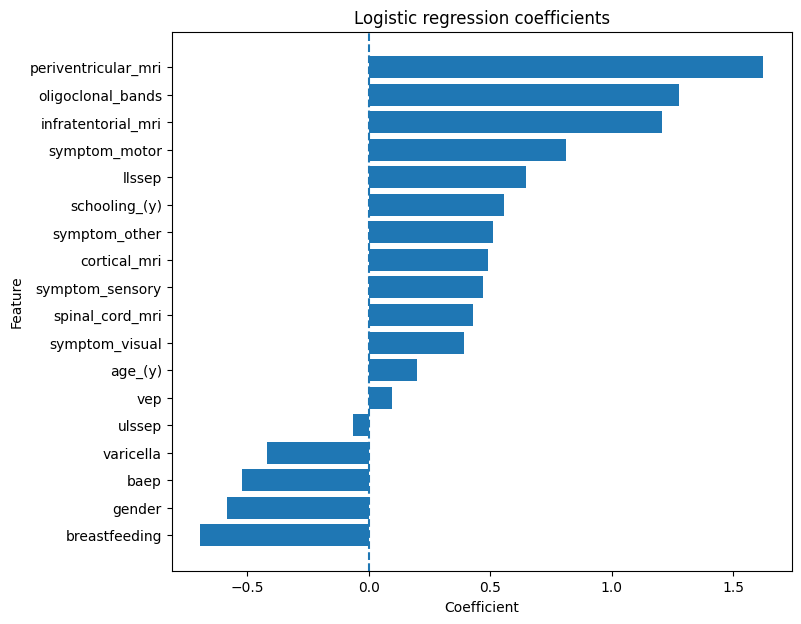

In [ ]:
import matplotlib.pyplot as plt

# sort coefficients for plotting
plot_data = coefficient_table.sort_values(by="coefficient")

# create coefficient plot
plt.figure(figsize=(8, 7))

plt.barh(
    plot_data["feature"],
    plot_data["coefficient"]
)

plt.axvline(0, linestyle="--")

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Logistic regression coefficients")

# save figure
plt.savefig("results/figures/logistic_regression_coefficients_without.png", dpi=300, bbox_inches="tight")

plt.show()